### XGBoost Boruta T20

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.multiclass import unique_labels
from sklearn.utils import resample
import xgboost as xgb
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt

# datapath
datapath = 'D:/fypadpm/dataset/CSECICIDS2018/'

In [2]:
import pandas as pd

# =====================================================
# 1️⃣ File paths
# =====================================================
paths = {
    "Train": datapath+"boruta_train_t20.csv",
    "Validation": datapath+"boruta_validation_t20.csv",
    "Test": datapath+"boruta_test_t20.csv"

}

# =====================================================
# 2️⃣ Read CSV files
# =====================================================
df_train = pd.read_csv(paths["Train"])
df_test = pd.read_csv(paths["Test"])
df_val = pd.read_csv(paths["Validation"])

print("Loaded datasets:")
print("Train:", df_train.shape)
print("Test:", df_test.shape)
print("Validation:", df_val.shape)

# =====================================================
# 3️⃣ Split into X and y
# =====================================================
# Training
X_train = df_train.drop(columns=["Label","Attack_Type"])
y_train = df_train["Attack_Type"]

# Validation
X_val = df_val.drop(columns=["Label", "Attack_Type"])
y_val = df_val["Attack_Type"]

# Testing
X_test = df_test.drop(columns=["Label","Attack_Type"])
y_test = df_test["Attack_Type"]

# =====================================================
# 4️⃣ Print final shapes
# =====================================================
print("\nFinal shapes:")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_val:", X_val.shape, " | y_val:", y_val.shape)
print("X_test:", X_test.shape, " | y_test:", y_test.shape)


Loaded datasets:
Train: (10415163, 22)
Test: (2719750, 22)
Validation: (2603791, 22)

Final shapes:
X_train: (10415163, 20)  | y_train: (10415163,)
X_val: (2603791, 20)  | y_val: (2603791,)
X_test: (2719750, 20)  | y_test: (2719750,)


In [3]:
import xgboost as xgb
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

best_score = -1
best_params = None
best_model = None

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

print("🔍 Starting validation-based hyperparameter search...\n")

for n in param_grid['n_estimators']:
    for md in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:

            print(f"Testing: n_estimators={n}, max_depth={md}, learning_rate={lr}")

            model = xgb.XGBClassifier(
                objective='multi:softprob',
                eval_metric='mlogloss',
                use_label_encoder=False,
                random_state=42,
                n_estimators=n,
                max_depth=md,
                learning_rate=lr
            )

            # Train on training set
            model.fit(X_train, y_train)

            # Validate
            y_pred_val = model.predict(X_val)
            val_acc = accuracy_score(y_val, y_pred_val)

            print(f" → Validation Accuracy: {val_acc:.5f}\n")

            # Track best
            if val_acc > best_score:
                best_score = val_acc
                best_params = {'n_estimators': n, 'max_depth': md, 'learning_rate': lr}
                best_model = model

print("==========================================")
print("Best Params:", best_params)
print("Best Validation Accuracy:", best_score)

joblib.dump(best_model, datapath+"xgb_boruta_t20_best_model.pkl")




🔍 Starting validation-based hyperparameter search...

Testing: n_estimators=100, max_depth=3, learning_rate=0.05


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:40:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98745

Testing: n_estimators=100, max_depth=3, learning_rate=0.1


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:45:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98829

Testing: n_estimators=100, max_depth=3, learning_rate=0.2


...

C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:34:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98915

Testing: n_estimators=300, max_depth=7, learning_rate=0.2


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:50:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98916

Best Params: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2}
Best Validation Accuracy: 0.9891627246580083


['D:/fypadpm/dataset/CSECICIDS2018/xgb_boruta_t20_best_model.pkl']

Loading model
Test metrics:
  Accuracy : 0.9816
  Precision: 0.9848
  Recall   : 0.9816
  F1-Score : 0.9814

Confusion Matrix (Raw Values):
[[2425510       6       0       2       2    3121       5]
 [      2   45981       0       0       0       0       0]
 [      0       0   12012       0       0       0       0]
 [      0       0       0   91143       0       1       0]
 [    108       0   29673       0   94598       0       0]
 [  17077       0       0       0       0     376       0]
 [     25       0       0       1       0       0     107]]

Confusion Matrix (Table with Original Attack Names):


,Pred Benign,Pred Bot,Pred Brute Force,Pred DDoS,Pred DoS,Pred Infiltration,Pred Web Attack
True Benign,2425510,6,0,2,2,3121,5
True Bot,2,45981,0,0,0,0,0
True Brute Force,0,0,12012,0,0,0,0
True DDoS,0,0,0,91143,0,1,0
True DoS,108,0,29673,0,94598,0,0
True Infiltration,17077,0,0,0,0,376,0
True Web Attack,25,0,0,1,0,0,107


<Figure size 1200x800 with 0 Axes>

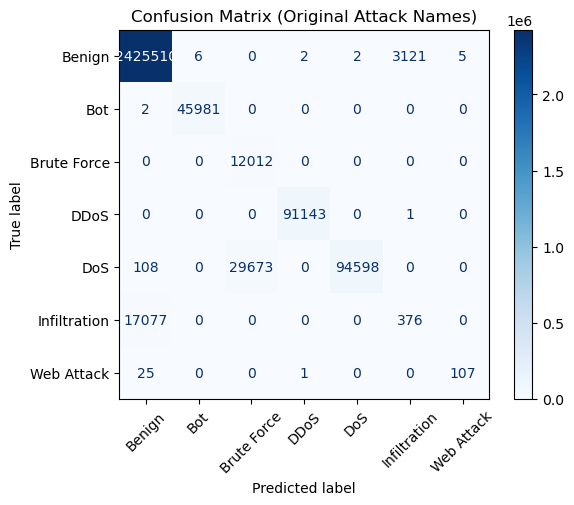

In [4]:
# Load and run best model to verify the result
import joblib
import pandas as pd

# ===== Paths =====
model_path   = datapath+"xgb_boruta_t20_best_model.pkl"

# ===== Load all objects =====
print("Loading model")

xgb_model = joblib.load(model_path)

# ===== Evaluate =====
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Test metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

# # ===== 8) Save artifacts =====
# joblib.dump(xgb_model, "D:/r6g/prog1/cicids2018/xgb_model.pkl")

# print("Saved: xgb_model.pkl")

import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# ===== Load JSON mapping =====
with open(r"D:\fypadpm\proj1\mappings.json", "r") as f:
    mapping = json.load(f)

attack_type_mapping = mapping["attack_type_mapping"]   # dict: "0": "Benign", ...

# ===== Prepare label names (sorted by integer key) =====
unique_labels = sorted(list(set(y_test)))
attack_type_names = [attack_type_mapping[str(l)] for l in unique_labels]

# ===== Confusion Matrix =====
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

print("\nConfusion Matrix (Raw Values):")
print(cm)

# ===== Table Format =====
cm_df = pd.DataFrame(
    cm,
    index=[f"True {attack_type_mapping[str(l)]}" for l in unique_labels],
    columns=[f"Pred {attack_type_mapping[str(l)]}" for l in unique_labels]
)

print("\nConfusion Matrix (Table with Original Attack Names):")
display(cm_df)

# ===== Heatmap Plot =====
plt.figure(figsize=(12, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_type_names)
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix (Original Attack Names)")
plt.show()


### XGBoost Boruta T30

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.multiclass import unique_labels
from sklearn.utils import resample
import xgboost as xgb
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt

# datapath
datapath = 'D:/fypadpm/dataset/CSECICIDS2018/'

In [6]:
import pandas as pd

# =====================================================
# 1️⃣ File paths
# =====================================================
paths = {
    "Train": datapath+"boruta_train_t30.csv",
    "Validation": datapath+"boruta_validation_t30.csv",
    "Test": datapath+"boruta_test_t30.csv"

}

# =====================================================
# 2️⃣ Read CSV files
# =====================================================
df_train = pd.read_csv(paths["Train"])
df_test = pd.read_csv(paths["Test"])
df_val = pd.read_csv(paths["Validation"])

print("Loaded datasets:")
print("Train:", df_train.shape)
print("Test:", df_test.shape)
print("Validation:", df_val.shape)

# =====================================================
# 3️⃣ Split into X and y
# =====================================================
# Training
X_train = df_train.drop(columns=["Label","Attack_Type"])
y_train = df_train["Attack_Type"]

# Validation
X_val = df_val.drop(columns=["Label", "Attack_Type"])
y_val = df_val["Attack_Type"]

# Testing
X_test = df_test.drop(columns=["Label","Attack_Type"])
y_test = df_test["Attack_Type"]

# =====================================================
# 4️⃣ Print final shapes
# =====================================================
print("\nFinal shapes:")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_val:", X_val.shape, " | y_val:", y_val.shape)
print("X_test:", X_test.shape, " | y_test:", y_test.shape)


Loaded datasets:
Train: (10415163, 32)
Test: (2719750, 32)
Validation: (2603791, 32)

Final shapes:
X_train: (10415163, 30)  | y_train: (10415163,)
X_val: (2603791, 30)  | y_val: (2603791,)
X_test: (2719750, 30)  | y_test: (2719750,)


In [7]:
import xgboost as xgb
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

best_score = -1
best_params = None
best_model = None

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

print("🔍 Starting validation-based hyperparameter search...\n")

for n in param_grid['n_estimators']:
    for md in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:

            print(f"Testing: n_estimators={n}, max_depth={md}, learning_rate={lr}")

            model = xgb.XGBClassifier(
                objective='multi:softprob',
                eval_metric='mlogloss',
                use_label_encoder=False,
                random_state=42,
                n_estimators=n,
                max_depth=md,
                learning_rate=lr
            )

            # Train on training set
            model.fit(X_train, y_train)

            # Validate
            y_pred_val = model.predict(X_val)
            val_acc = accuracy_score(y_val, y_pred_val)

            print(f" → Validation Accuracy: {val_acc:.5f}\n")

            # Track best
            if val_acc > best_score:
                best_score = val_acc
                best_params = {'n_estimators': n, 'max_depth': md, 'learning_rate': lr}
                best_model = model

print("==========================================")
print("Best Params:", best_params)
print("Best Validation Accuracy:", best_score)

joblib.dump(best_model, datapath+"xgb_boruta_t30_best_model.pkl")




🔍 Starting validation-based hyperparameter search...

Testing: n_estimators=100, max_depth=3, learning_rate=0.05


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:08:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98744

Testing: n_estimators=100, max_depth=3, learning_rate=0.1


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:13:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98841

Testing: n_estimators=100, max_depth=3, learning_rate=0.2


...

C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:57:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98916

Testing: n_estimators=300, max_depth=7, learning_rate=0.2


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:18:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98917

Best Params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2}
Best Validation Accuracy: 0.9891715579322611


['D:/fypadpm/dataset/CSECICIDS2018/xgb_boruta_t30_best_model.pkl']

Loading model
Test metrics:
  Accuracy : 0.9816
  Precision: 0.9848
  Recall   : 0.9816
  F1-Score : 0.9814

Confusion Matrix (Raw Values):
[[2425611       6       0       2       1    3021       5]
 [      2   45981       0       0       0       0       0]
 [      0       0   12012       0       0       0       0]
 [      0       0       0   91144       0       0       0]
 [    153       0   29673       0   94553       0       0]
 [  17079       0       0       0       0     374       0]
 [     25       0       0       1       0       0     107]]

Confusion Matrix (Table with Original Attack Names):


,Pred Benign,Pred Bot,Pred Brute Force,Pred DDoS,Pred DoS,Pred Infiltration,Pred Web Attack
True Benign,2425611,6,0,2,1,3021,5
True Bot,2,45981,0,0,0,0,0
True Brute Force,0,0,12012,0,0,0,0
True DDoS,0,0,0,91144,0,0,0
True DoS,153,0,29673,0,94553,0,0
True Infiltration,17079,0,0,0,0,374,0
True Web Attack,25,0,0,1,0,0,107


<Figure size 1200x800 with 0 Axes>

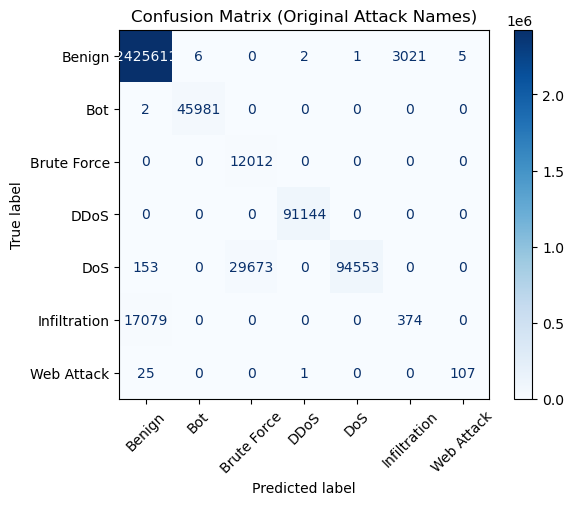

In [8]:
# Load and run best model to verify the result
import joblib
import pandas as pd

# ===== Paths =====
model_path   = datapath+"xgb_boruta_t30_best_model.pkl"

# ===== Load all objects =====
print("Loading model")

xgb_model = joblib.load(model_path)

# ===== Evaluate =====
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Test metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

# # ===== 8) Save artifacts =====
# joblib.dump(xgb_model, "D:/r6g/prog1/cicids2018/xgb_model.pkl")

# print("Saved: xgb_model.pkl")

import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# ===== Load JSON mapping =====
with open(r"D:\fypadpm\proj1\mappings.json", "r") as f:
    mapping = json.load(f)

attack_type_mapping = mapping["attack_type_mapping"]   # dict: "0": "Benign", ...

# ===== Prepare label names (sorted by integer key) =====
unique_labels = sorted(list(set(y_test)))
attack_type_names = [attack_type_mapping[str(l)] for l in unique_labels]

# ===== Confusion Matrix =====
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

print("\nConfusion Matrix (Raw Values):")
print(cm)

# ===== Table Format =====
cm_df = pd.DataFrame(
    cm,
    index=[f"True {attack_type_mapping[str(l)]}" for l in unique_labels],
    columns=[f"Pred {attack_type_mapping[str(l)]}" for l in unique_labels]
)

print("\nConfusion Matrix (Table with Original Attack Names):")
display(cm_df)

# ===== Heatmap Plot =====
plt.figure(figsize=(12, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_type_names)
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix (Original Attack Names)")
plt.show()


## Top 10

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.multiclass import unique_labels
from sklearn.utils import resample
import xgboost as xgb
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt

# datapath
datapath = 'D:/fypadpm/dataset/CSECICIDS2018/'

In [10]:
import pandas as pd

# =====================================================
# 1️⃣ File paths
# =====================================================
paths = {
    "Train": datapath+"boruta_train_t10.csv",
    "Validation": datapath+"boruta_validation_t10.csv",
    "Test": datapath+"boruta_test_t10.csv"

}

# =====================================================
# 2️⃣ Read CSV files
# =====================================================
df_train = pd.read_csv(paths["Train"])
df_test = pd.read_csv(paths["Test"])
df_val = pd.read_csv(paths["Validation"])

print("Loaded datasets:")
print("Train:", df_train.shape)
print("Test:", df_test.shape)
print("Validation:", df_val.shape)

# =====================================================
# 3️⃣ Split into X and y
# =====================================================
# Training
X_train = df_train.drop(columns=["Label","Attack_Type"])
y_train = df_train["Attack_Type"]

# Validation
X_val = df_val.drop(columns=["Label", "Attack_Type"])
y_val = df_val["Attack_Type"]

# Testing
X_test = df_test.drop(columns=["Label","Attack_Type"])
y_test = df_test["Attack_Type"]

# =====================================================
# 4️⃣ Print final shapes
# =====================================================
print("\nFinal shapes:")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_val:", X_val.shape, " | y_val:", y_val.shape)
print("X_test:", X_test.shape, " | y_test:", y_test.shape)


Loaded datasets:
Train: (10415163, 12)
Test: (2719750, 12)
Validation: (2603791, 12)

Final shapes:
X_train: (10415163, 10)  | y_train: (10415163,)
X_val: (2603791, 10)  | y_val: (2603791,)
X_test: (2719750, 10)  | y_test: (2719750,)


In [11]:
import xgboost as xgb
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

best_score = -1
best_params = None
best_model = None

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

print("🔍 Starting validation-based hyperparameter search...\n")

for n in param_grid['n_estimators']:
    for md in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:

            print(f"Testing: n_estimators={n}, max_depth={md}, learning_rate={lr}")

            model = xgb.XGBClassifier(
                objective='multi:softprob',
                eval_metric='mlogloss',
                use_label_encoder=False,
                random_state=42,
                n_estimators=n,
                max_depth=md,
                learning_rate=lr
            )

            # Train on training set
            model.fit(X_train, y_train)

            # Validate
            y_pred_val = model.predict(X_val)
            val_acc = accuracy_score(y_val, y_pred_val)

            print(f" → Validation Accuracy: {val_acc:.5f}\n")

            # Track best
            if val_acc > best_score:
                best_score = val_acc
                best_params = {'n_estimators': n, 'max_depth': md, 'learning_rate': lr}
                best_model = model

print("==========================================")
print("Best Params:", best_params)
print("Best Validation Accuracy:", best_score)

joblib.dump(best_model, datapath+"xgb_boruta_t10_best_model.pkl")




🔍 Starting validation-based hyperparameter search...

Testing: n_estimators=100, max_depth=3, learning_rate=0.05


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:14:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98774

Testing: n_estimators=100, max_depth=3, learning_rate=0.1


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:18:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98865

Testing: n_estimators=100, max_depth=3, learning_rate=0.2


...

C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:36:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98914

Testing: n_estimators=300, max_depth=7, learning_rate=0.2


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:50:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98913

Best Params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1}
Best Validation Accuracy: 0.9891431378324912


['D:/fypadpm/dataset/CSECICIDS2018/xgb_boruta_t10_best_model.pkl']

Loading model
Test metrics:
  Accuracy : 0.9817
  Precision: 0.9848
  Recall   : 0.9817
  F1-Score : 0.9814

Confusion Matrix (Raw Values):
[[2425798       7       0       2       4    2830       5]
 [      2   45981       0       0       0       0       0]
 [      0       0   12012       0       0       0       0]
 [      0       0       0   91144       0       0       0]
 [    156       0   29673       0   94550       0       0]
 [  17122       0       0       0       0     331       0]
 [     23       0       0       1       0       0     109]]

Confusion Matrix (Table with Original Attack Names):


,Pred Benign,Pred Bot,Pred Brute Force,Pred DDoS,Pred DoS,Pred Infiltration,Pred Web Attack
True Benign,2425798,7,0,2,4,2830,5
True Bot,2,45981,0,0,0,0,0
True Brute Force,0,0,12012,0,0,0,0
True DDoS,0,0,0,91144,0,0,0
True DoS,156,0,29673,0,94550,0,0
True Infiltration,17122,0,0,0,0,331,0
True Web Attack,23,0,0,1,0,0,109


<Figure size 1200x800 with 0 Axes>

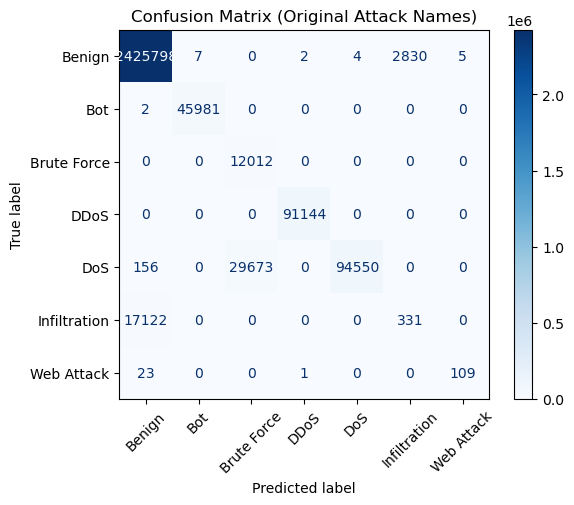

In [12]:
# Load and run best model to verify the result
import joblib
import pandas as pd

# ===== Paths =====
model_path   = datapath+"xgb_boruta_t10_best_model.pkl"

# ===== Load all objects =====
print("Loading model")

xgb_model = joblib.load(model_path)

# ===== Evaluate =====
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Test metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

# # ===== 8) Save artifacts =====
# joblib.dump(xgb_model, "D:/r6g/prog1/cicids2018/xgb_model.pkl")

# print("Saved: xgb_model.pkl")

import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# ===== Load JSON mapping =====
with open(r"D:\fypadpm\proj1\mappings.json", "r") as f:
    mapping = json.load(f)

attack_type_mapping = mapping["attack_type_mapping"]   # dict: "0": "Benign", ...

# ===== Prepare label names (sorted by integer key) =====
unique_labels = sorted(list(set(y_test)))
attack_type_names = [attack_type_mapping[str(l)] for l in unique_labels]

# ===== Confusion Matrix =====
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

print("\nConfusion Matrix (Raw Values):")
print(cm)

# ===== Table Format =====
cm_df = pd.DataFrame(
    cm,
    index=[f"True {attack_type_mapping[str(l)]}" for l in unique_labels],
    columns=[f"Pred {attack_type_mapping[str(l)]}" for l in unique_labels]
)

print("\nConfusion Matrix (Table with Original Attack Names):")
display(cm_df)

# ===== Heatmap Plot =====
plt.figure(figsize=(12, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_type_names)
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix (Original Attack Names)")
plt.show()


### XGBoost With Downsampling

In [13]:
import pandas as pd

# =====================================================
# 1️⃣ File paths
# =====================================================
paths = {
        "Train": datapath+"Boruta_train_t10.csv",
        "Validation": datapath+"Boruta_validation_t10.csv",
        "Test": datapath+"Boruta_test_t10.csv"

}

# =====================================================
# 2️⃣ Read CSV files
# =====================================================
df_train = pd.read_csv(paths["Train"])
df_test = pd.read_csv(paths["Test"])
df_val = pd.read_csv(paths["Validation"])

print("Loaded datasets:")
print("Train:", df_train.shape)
print("Test:", df_test.shape)
print("Validation:", df_val.shape)

# =====================================================
# 3️⃣ Split into X and y
# =====================================================
# Training
X_train = df_train.drop(columns=["Label","Attack_Type"])
y_train = df_train["Attack_Type"]

# Validation
X_val = df_val.drop(columns=["Label", "Attack_Type"])
y_val = df_val["Attack_Type"]

# Testing
X_test = df_test.drop(columns=["Label","Attack_Type"])
y_test = df_test["Attack_Type"]

# =====================================================
# 4️⃣ Print final shapes
# =====================================================
print("\nFinal shapes:")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_val:", X_val.shape, " | y_val:", y_val.shape)
print("X_test:", X_test.shape, " | y_test:", y_test.shape)

Loaded datasets:
Train: (10415163, 12)
Test: (2719750, 12)
Validation: (2603791, 12)

Final shapes:
X_train: (10415163, 10)  | y_train: (10415163,)
X_val: (2603791, 10)  | y_val: (2603791,)
X_test: (2719750, 10)  | y_test: (2719750,)


In [14]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# ------------ Downsampling -----------------
train_data = X_train.copy()
train_data['Attack_Type'] = y_train.values

majority_class = train_data[train_data['Attack_Type'] == train_data['Attack_Type'].value_counts().idxmax()]
minority_class = train_data[train_data['Attack_Type'] != train_data['Attack_Type'].value_counts().idxmax()]

majority_downsampled = resample(
    majority_class,
    replace=False,
    n_samples=len(minority_class),
    random_state=42
)

train_balanced = pd.concat([majority_downsampled, minority_class])
X_train = train_balanced.drop(columns=['Attack_Type'])
y_train = train_balanced['Attack_Type']

# -----------------------------------------------------

best_score = -1
best_params = None
best_model = None

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

print("🔍 Starting validation-based hyperparameter search...\n")

for n in param_grid['n_estimators']:
    for md in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:

            print(f"Testing: n_estimators={n}, max_depth={md}, learning_rate={lr}")

            model = xgb.XGBClassifier(
                objective='multi:softprob',
                eval_metric='mlogloss',
                use_label_encoder=False,
                random_state=42,
                n_estimators=n,
                max_depth=md,
                learning_rate=lr
            )

            # Train on training set
            model.fit(X_train, y_train)

            # Validate
            y_pred_val = model.predict(X_val)
            val_acc = accuracy_score(y_val, y_pred_val)

            print(f" → Validation Accuracy: {val_acc:.5f}\n")

            # Track best
            if val_acc > best_score:
                best_score = val_acc
                best_params = {'n_estimators': n, 'max_depth': md, 'learning_rate': lr}
                best_model = model

print("==========================================")
print("Best Params:", best_params)
print("Best Validation Accuracy:", best_score)

joblib.dump(best_model, datapath+"xgb_DS_best_model.pkl")
print("Saved: xgb_DS_best_model.pkl")

🔍 Starting validation-based hyperparameter search...

Testing: n_estimators=100, max_depth=3, learning_rate=0.05


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:05:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98129

Testing: n_estimators=100, max_depth=3, learning_rate=0.1


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:06:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98658

Testing: n_estimators=100, max_depth=3, learning_rate=0.2


...

 → Validation Accuracy: 0.98738

Testing: n_estimators=300, max_depth=7, learning_rate=0.1


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:12:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98730

Testing: n_estimators=300, max_depth=7, learning_rate=0.2


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:17:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98429

Best Params: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05}
Best Validation Accuracy: 0.9874813301067559
Saved: xgb_DS_best_model.pkl


Loading model
Test metrics:
  Accuracy : 0.9794
  Precision: 0.9852
  Recall   : 0.9794
  F1-Score : 0.9807

Confusion Matrix (Raw Values):
[[2418707      52      50     197      38    9595       7]
 [      0   45983       0       0       0       0       0]
 [      0       0   12012       0       0       0       0]
 [     76       0       0   91068       0       0       0]
 [    106       0   29673       0   94600       0       0]
 [  16069       0       0       3       0    1381       0]
 [     25       0       0       1       0       0     107]]

Confusion Matrix (Table with Original Attack Names):


,Pred Benign,Pred Bot,Pred Brute Force,Pred DDoS,Pred DoS,Pred Infiltration,Pred Web Attack
True Benign,2418707,52,50,197,38,9595,7
True Bot,0,45983,0,0,0,0,0
True Brute Force,0,0,12012,0,0,0,0
True DDoS,76,0,0,91068,0,0,0
True DoS,106,0,29673,0,94600,0,0
True Infiltration,16069,0,0,3,0,1381,0
True Web Attack,25,0,0,1,0,0,107


<Figure size 1200x800 with 0 Axes>

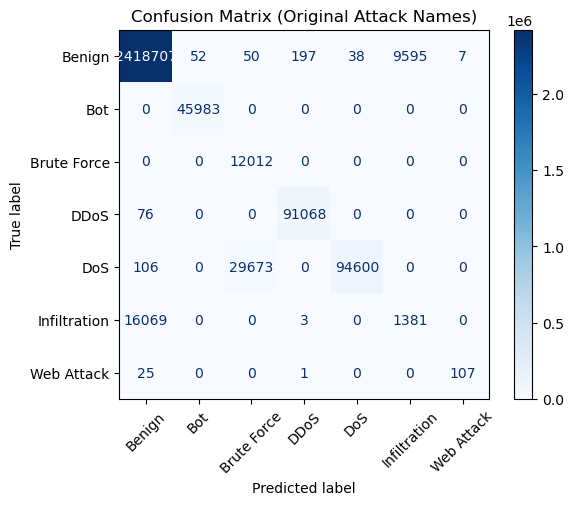

In [15]:
import joblib
import pandas as pd

# ===== Paths =====
model_path   = datapath+"xgb_DS_best_model.pkl"

# ===== Load all objects =====
print("Loading model")

xgb_model = joblib.load(model_path)

# ===== Evaluate =====
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Test metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

# # ===== 8) Save artifacts =====
# joblib.dump(xgb_model, "D:/r6g/prog1/cicids2018/xgb_DS_best_model.pkl")

# print("Saved: xgb_model.pkl")

import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# ===== Load JSON mapping =====
with open(r"D:\fypadpm\proj1\mappings.json", "r") as f:
    mapping = json.load(f)

attack_type_mapping = mapping["attack_type_mapping"]   # dict: "0": "Benign", ...

# ===== Prepare label names (sorted by integer key) =====
unique_labels = sorted(list(set(y_test)))
attack_type_names = [attack_type_mapping[str(l)] for l in unique_labels]

# ===== Confusion Matrix =====
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

print("\nConfusion Matrix (Raw Values):")
print(cm)

# ===== Table Format =====
cm_df = pd.DataFrame(
    cm,
    index=[f"True {attack_type_mapping[str(l)]}" for l in unique_labels],
    columns=[f"Pred {attack_type_mapping[str(l)]}" for l in unique_labels]
)

print("\nConfusion Matrix (Table with Original Attack Names):")
display(cm_df)

# ===== Heatmap Plot =====
plt.figure(figsize=(12, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_type_names)
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix (Original Attack Names)")
plt.show()


### XGBoost with SOMTE and Tomek Link 1

In [16]:
import pandas as pd

# =====================================================
# 1️⃣ File paths
# =====================================================
paths = {
        "Train": datapath+"Boruta_train_t10.csv",
        "Validation": datapath+"Boruta_validation_t10.csv",
        "Test": datapath+"Boruta_test_t10.csv"

}

# =====================================================
# 2️⃣ Read CSV files
# =====================================================
df_train = pd.read_csv(paths["Train"])
df_test = pd.read_csv(paths["Test"])
df_val = pd.read_csv(paths["Validation"])

print("Loaded datasets:")
print("Train:", df_train.shape)
print("Test:", df_test.shape)
print("Validation:", df_val.shape)

# =====================================================
# 3️⃣ Split into X and y
# =====================================================
# Training
X_train = df_train.drop(columns=["Label","Attack_Type"])
y_train = df_train["Attack_Type"]

# Validation
X_val = df_val.drop(columns=["Label", "Attack_Type"])
y_val = df_val["Attack_Type"]

# Testing
X_test = df_test.drop(columns=["Label","Attack_Type"])
y_test = df_test["Attack_Type"]

# =====================================================
# 4️⃣ Print final shapes
# =====================================================
print("\nFinal shapes:")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_val:", X_val.shape, " | y_val:", y_val.shape)
print("X_test:", X_test.shape, " | y_test:", y_test.shape)

Loaded datasets:
Train: (10415163, 12)
Test: (2719750, 12)
Validation: (2603791, 12)

Final shapes:
X_train: (10415163, 10)  | y_train: (10415163,)
X_val: (2603791, 10)  | y_val: (2603791,)
X_test: (2719750, 10)  | y_test: (2719750,)


📊 Distribution BEFORE:


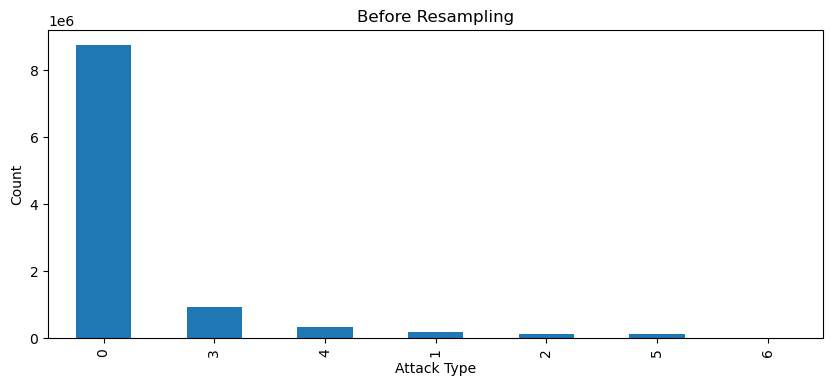

Original counts: Counter({0: 8757478, 3: 924193, 4: 313548, 1: 189062, 2: 115725, 5: 114520, 6: 637})
Label 5: from 114520 → 229040
Label 6: from 637 → 3185

After SMOTE:
Counter({0: 8757478, 3: 924193, 4: 313548, 5: 229040, 1: 189062, 2: 115725, 6: 3185})

💾 Saved cleaned training data → boruta_SM_TL_train.csv
📊 Distribution AFTER:


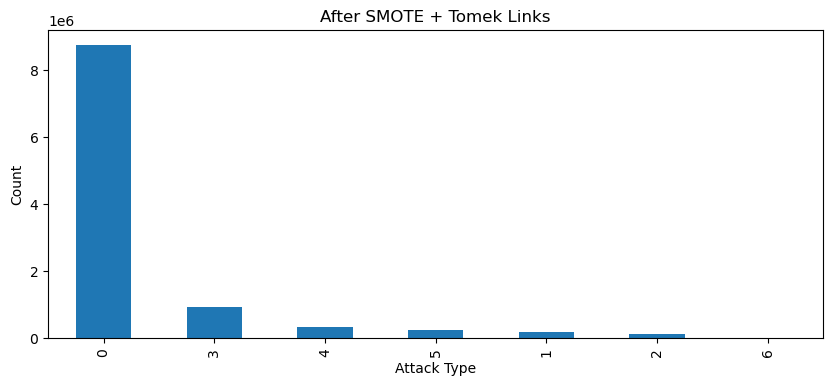


🔍 Starting XGBoost hyperparameter search...

Testing: n_estimators=100, max_depth=3, learning_rate=0.05


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:25:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98757

Testing: n_estimators=100, max_depth=3, learning_rate=0.1


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:29:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98838

Testing: n_estimators=100, max_depth=3, learning_rate=0.2


...

 → Validation Accuracy: 0.98897

Testing: n_estimators=300, max_depth=7, learning_rate=0.1


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:46:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98896

Testing: n_estimators=300, max_depth=7, learning_rate=0.2


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.97201

Best Params: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05}
Best Validation Accuracy: 0.9889714650676648

💾 Best model saved → D:/fypadpm/dataset/CSECICIDS2018/xgb_SMOTE_Tomek_best_model1.pkl


In [17]:
# =====================================================
# Imports
# =====================================================
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.metrics import accuracy_score
import xgboost as xgb
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


# =====================================================
# Distribution Plot
# =====================================================
def plot_distribution(y, title):
    plt.figure(figsize=(10,4))
    pd.Series(y).value_counts().plot(kind='bar')
    plt.title(title)
    plt.xlabel("Attack Type")
    plt.ylabel("Count")
    plt.show()


print("📊 Distribution BEFORE:")
plot_distribution(y_train, "Before Resampling")

print("Original counts:", Counter(y_train))


# =====================================================
# 1️⃣ SMOTE — Increase Label 5 (+100%) & Label 6 (+500%)
# =====================================================

orig_c5 = Counter(y_train)[5]
orig_c6 = Counter(y_train)[6]

# 100% increase → new count = 2 × original
target_c5 = orig_c5 * 2

# 500% increase → new count = 5 × original
target_c6 = orig_c6 * 5

print(f"Label 5: from {orig_c5} → {target_c5}")
print(f"Label 6: from {orig_c6} → {target_c6}")

smote_strategy = {
    5: target_c5,
    6: target_c6
}

sm = SMOTE(
    sampling_strategy=smote_strategy,
    k_neighbors=5,
    random_state=42
)

X_sm, y_sm = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(Counter(y_sm))


# # =====================================================
# # 2️⃣ Tomek Links — reduce majority classes
# # =====================================================
# tl = TomekLinks(sampling_strategy="majority")

# X_clean, y_clean = tl.fit_resample(X_sm, y_sm)

# print("\nAfter Tomek Links:")
# print(Counter(y_clean))

####### Bypass Tomek Links
X_clean = X_sm
y_clean = y_sm

# =====================================================
# 3️⃣ Save the cleaned training dataset
# =====================================================
boruta_SM_TL_train = pd.concat(
    [pd.DataFrame(X_clean, columns=X_train.columns),
     pd.Series(y_clean, name="Attack_Type")],
    axis=1
)

boruta_SM_TL_train.to_csv("boruta_SM_TL_train1.csv", index=False)
print("\n💾 Saved cleaned training data → boruta_SM_TL_train.csv")


# =====================================================
# 4️⃣ Plot final distribution
# =====================================================
print("📊 Distribution AFTER:")
plot_distribution(y_clean, "After SMOTE + Tomek Links")


# Replace training sets
X_train = X_clean
y_train = y_clean


# =====================================================
# 5️⃣ XGBoost Hyperparameter Search
# =====================================================
best_score = -1
best_params = None
best_model = None

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

print("\n🔍 Starting XGBoost hyperparameter search...\n")

for n in param_grid['n_estimators']:
    for md in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:

            print(f"Testing: n_estimators={n}, max_depth={md}, learning_rate={lr}")

            model = xgb.XGBClassifier(
                objective='multi:softprob',
                eval_metric='mlogloss',
                use_label_encoder=False,
                random_state=42,
                n_estimators=n,
                max_depth=md,
                learning_rate=lr
            )

            model.fit(X_train, y_train)

            y_pred_val = model.predict(X_val)
            val_acc = accuracy_score(y_val, y_pred_val)

            print(f" → Validation Accuracy: {val_acc:.5f}\n")

            if val_acc > best_score:
                best_score = val_acc
                best_params = {
                    'n_estimators': n,
                    'max_depth': md,
                    'learning_rate': lr
                }
                best_model = model


print("==========================================")
print("Best Params:", best_params)
print("Best Validation Accuracy:", best_score)


# =====================================================
# 6️⃣ Save the Best Model
# =====================================================
model_path = datapath+"xgb_SMOTE_Tomek_best_model1.pkl"
joblib.dump(best_model, model_path)
print(f"\n💾 Best model saved → {model_path}")


Loading model
Test metrics:
  Accuracy : 0.9812
  Precision: 0.9844
  Recall   : 0.9812
  F1-Score : 0.9811

Confusion Matrix (Raw Values):
[[2424596       8       5      13      18    3966      40]
 [      0   45983       0       0       0       0       0]
 [      0       0   12012       0       0       0       0]
 [     54       0       0   91090       0       0       0]
 [    157       0   29673       0   94549       0       0]
 [  17189       0       0       0       0     264       0]
 [     26       0       0       1       0       0     106]]

Confusion Matrix (Table with Original Attack Names):


,Pred Benign,Pred Bot,Pred Brute Force,Pred DDoS,Pred DoS,Pred Infiltration,Pred Web Attack
True Benign,2424596,8,5,13,18,3966,40
True Bot,0,45983,0,0,0,0,0
True Brute Force,0,0,12012,0,0,0,0
True DDoS,54,0,0,91090,0,0,0
True DoS,157,0,29673,0,94549,0,0
True Infiltration,17189,0,0,0,0,264,0
True Web Attack,26,0,0,1,0,0,106


<Figure size 1200x800 with 0 Axes>

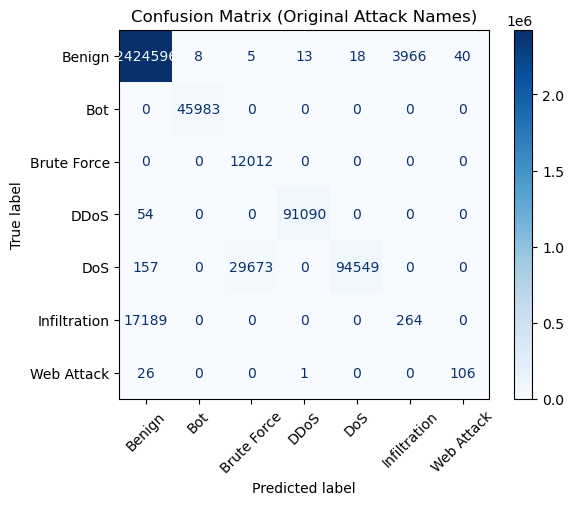

In [18]:
import joblib
import pandas as pd

# ===== Paths =====
model_path   = datapath+"xgb_SMOTE_Tomek_best_model1.pkl"

# ===== Load all objects =====
print("Loading model")

xgb_model = joblib.load(model_path)

# ===== Evaluate =====
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Test metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

# # ===== 8) Save artifacts =====
# joblib.dump(xgb_model, "D:/r6g/prog1/cicids2018/xgb_DS_best_model.pkl")

# print("Saved: xgb_model.pkl")

import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# ===== Load JSON mapping =====
with open(r"D:\fypadpm\proj1\mappings.json", "r") as f:
    mapping = json.load(f)

attack_type_mapping = mapping["attack_type_mapping"]   # dict: "0": "Benign", ...

# ===== Prepare label names (sorted by integer key) =====
unique_labels = sorted(list(set(y_test)))
attack_type_names = [attack_type_mapping[str(l)] for l in unique_labels]

# ===== Confusion Matrix =====
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

print("\nConfusion Matrix (Raw Values):")
print(cm)

# ===== Table Format =====
cm_df = pd.DataFrame(
    cm,
    index=[f"True {attack_type_mapping[str(l)]}" for l in unique_labels],
    columns=[f"Pred {attack_type_mapping[str(l)]}" for l in unique_labels]
)

print("\nConfusion Matrix (Table with Original Attack Names):")
display(cm_df)

# ===== Heatmap Plot =====
plt.figure(figsize=(12, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_type_names)
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix (Original Attack Names)")
plt.show()

### XGBoost with SOMTE and Tomek Link + downsampling

In [19]:
import pandas as pd

# =====================================================
# 1️⃣ File paths
# =====================================================
paths = {
        "Train": datapath+"Boruta_train_t10.csv",
        "Validation": datapath+"Boruta_validation_t10.csv",
        "Test": datapath+"Boruta_test_t10.csv"

}

# =====================================================
# 2️⃣ Read CSV files
# =====================================================
df_train = pd.read_csv(paths["Train"])
df_test = pd.read_csv(paths["Test"])
df_val = pd.read_csv(paths["Validation"])

print("Loaded datasets:")
print("Train:", df_train.shape)
print("Test:", df_test.shape)
print("Validation:", df_val.shape)

# =====================================================
# 3️⃣ Split into X and y
# =====================================================
# Training
X_train = df_train.drop(columns=["Label","Attack_Type"])
y_train = df_train["Attack_Type"]

# Validation
X_val = df_val.drop(columns=["Label", "Attack_Type"])
y_val = df_val["Attack_Type"]

# Testing
X_test = df_test.drop(columns=["Label","Attack_Type"])
y_test = df_test["Attack_Type"]

# =====================================================
# 4️⃣ Print final shapes
# =====================================================
print("\nFinal shapes:")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_val:", X_val.shape, " | y_val:", y_val.shape)
print("X_test:", X_test.shape, " | y_test:", y_test.shape)

Loaded datasets:
Train: (10415163, 12)
Test: (2719750, 12)
Validation: (2603791, 12)

Final shapes:
X_train: (10415163, 10)  | y_train: (10415163,)
X_val: (2603791, 10)  | y_val: (2603791,)
X_test: (2719750, 10)  | y_test: (2719750,)


📊 Distribution BEFORE:


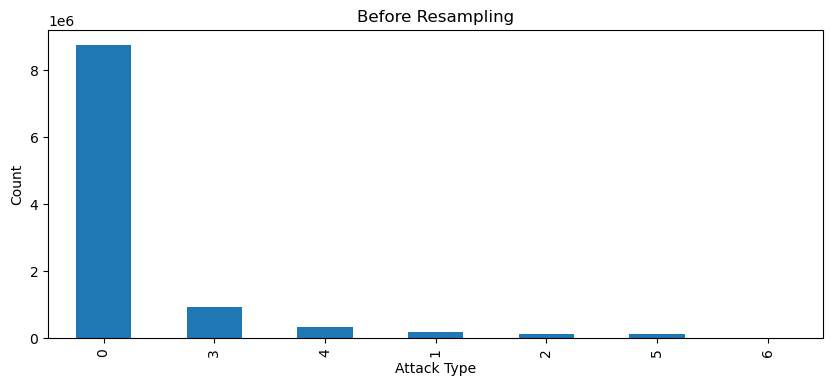

Original counts: Counter({0: 8757478, 3: 924193, 4: 313548, 1: 189062, 2: 115725, 5: 114520, 6: 637})
Label 5: from 114520 → 229040
Label 6: from 637 → 3185

After SMOTE:
Counter({0: 1657685, 3: 924193, 4: 313548, 5: 229040, 1: 189062, 2: 115725, 6: 3185})

💾 Saved cleaned training data → boruta_SM_TL_train.csv
📊 Distribution AFTER:


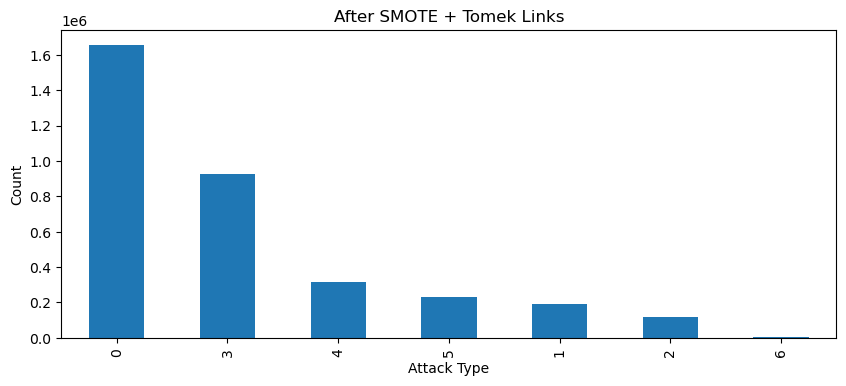


🔍 Starting XGBoost hyperparameter search...

Testing: n_estimators=100, max_depth=3, learning_rate=0.05


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:15:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98160

Testing: n_estimators=100, max_depth=3, learning_rate=0.1


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:16:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98344

Testing: n_estimators=100, max_depth=3, learning_rate=0.2


...

 → Validation Accuracy: 0.98496

Testing: n_estimators=300, max_depth=7, learning_rate=0.1


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:24:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98463

Testing: n_estimators=300, max_depth=7, learning_rate=0.2


C:\Users\loke\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:29:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98431

Best Params: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05}
Best Validation Accuracy: 0.9869939638012422

💾 Best model saved → D:/fypadpm/dataset/CSECICIDS2018/xgb_SMOTE_Tomek_best_model2.pkl


In [20]:
# =====================================================
# Imports
# =====================================================
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.metrics import accuracy_score
import xgboost as xgb
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


# =====================================================
# Distribution Plot
# =====================================================
def plot_distribution(y, title):
    plt.figure(figsize=(10,4))
    pd.Series(y).value_counts().plot(kind='bar')
    plt.title(title)
    plt.xlabel("Attack Type")
    plt.ylabel("Count")
    plt.show()


print("📊 Distribution BEFORE:")
plot_distribution(y_train, "Before Resampling")

print("Original counts:", Counter(y_train))


# ------------ Downsampling -----------------
train_data = X_train.copy()
train_data['Attack_Type'] = y_train.values

majority_class = train_data[train_data['Attack_Type'] == train_data['Attack_Type'].value_counts().idxmax()]
minority_class = train_data[train_data['Attack_Type'] != train_data['Attack_Type'].value_counts().idxmax()]

majority_downsampled = resample(
    majority_class,
    replace=False,
    n_samples=len(minority_class),
    random_state=42
)

train_balanced = pd.concat([majority_downsampled, minority_class])
X_train = train_balanced.drop(columns=['Attack_Type'])
y_train = train_balanced['Attack_Type']

# -----------------------------------------------------


# =====================================================
# 1️⃣ SMOTE — Increase Label 5 (+100%) & Label 6 (+500%)
# =====================================================

orig_c5 = Counter(y_train)[5]
orig_c6 = Counter(y_train)[6]

# 100% increase → new count = 2 × original
target_c5 = orig_c5 * 2

# 500% increase → new count = 5 × original
target_c6 = orig_c6 * 5

print(f"Label 5: from {orig_c5} → {target_c5}")
print(f"Label 6: from {orig_c6} → {target_c6}")

smote_strategy = {
    5: target_c5,
    6: target_c6
}

sm = SMOTE(
    sampling_strategy=smote_strategy,
    k_neighbors=5,
    random_state=42
)

X_sm, y_sm = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(Counter(y_sm))


# # =====================================================
# # 2️⃣ Tomek Links — reduce majority classes
# # =====================================================
# tl = TomekLinks(sampling_strategy="majority")

# X_clean, y_clean = tl.fit_resample(X_sm, y_sm)

# print("\nAfter Tomek Links:")
# print(Counter(y_clean))


####### Bypass Tomek Links
X_clean = X_sm
y_clean = y_sm


# =====================================================
# 3️⃣ Save the cleaned training dataset
# =====================================================
boruta_SM_TL_train = pd.concat(
    [pd.DataFrame(X_clean, columns=X_train.columns),
     pd.Series(y_clean, name="Attack_Type")],
    axis=1
)

boruta_SM_TL_train.to_csv(datapath+"boruta_SM_TL_train.csv", index=False)
print("\n💾 Saved cleaned training data → boruta_SM_TL_train.csv")


# =====================================================
# 4️⃣ Plot final distribution
# =====================================================
print("📊 Distribution AFTER:")
plot_distribution(y_clean, "After SMOTE + Tomek Links")


# Replace training sets
X_train = X_clean
y_train = y_clean


# =====================================================
# 5️⃣ XGBoost Hyperparameter Search
# =====================================================
best_score = -1
best_params = None
best_model = None

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

print("\n🔍 Starting XGBoost hyperparameter search...\n")

for n in param_grid['n_estimators']:
    for md in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:

            print(f"Testing: n_estimators={n}, max_depth={md}, learning_rate={lr}")

            model = xgb.XGBClassifier(
                objective='multi:softprob',
                eval_metric='mlogloss',
                use_label_encoder=False,
                random_state=42,
                n_estimators=n,
                max_depth=md,
                learning_rate=lr
            )

            model.fit(X_train, y_train)

            y_pred_val = model.predict(X_val)
            val_acc = accuracy_score(y_val, y_pred_val)

            print(f" → Validation Accuracy: {val_acc:.5f}\n")

            if val_acc > best_score:
                best_score = val_acc
                best_params = {
                    'n_estimators': n,
                    'max_depth': md,
                    'learning_rate': lr
                }
                best_model = model


print("==========================================")
print("Best Params:", best_params)
print("Best Validation Accuracy:", best_score)


# =====================================================
# 6️⃣ Save the Best Model
# =====================================================
model_path = datapath+"xgb_SMOTE_Tomek_best_model2.pkl"
joblib.dump(best_model, model_path)
print(f"\n💾 Best model saved → {model_path}")


Loading model
Test metrics:
  Accuracy : 0.9790
  Precision: 0.9852
  Recall   : 0.9790
  F1-Score : 0.9804

Confusion Matrix (Raw Values):
[[2417310      23      42     220      38   11000      13]
 [      0   45983       0       0       0       0       0]
 [      0       0   12012       0       0       0       0]
 [     56       0       0   91088       0       0       0]
 [    154       0   29673       0   94552       0       0]
 [  15944       0       0       0       0    1507       2]
 [     22       0       0       1       0       0     110]]

Confusion Matrix (Table with Original Attack Names):


,Pred Benign,Pred Bot,Pred Brute Force,Pred DDoS,Pred DoS,Pred Infiltration,Pred Web Attack
True Benign,2417310,23,42,220,38,11000,13
True Bot,0,45983,0,0,0,0,0
True Brute Force,0,0,12012,0,0,0,0
True DDoS,56,0,0,91088,0,0,0
True DoS,154,0,29673,0,94552,0,0
True Infiltration,15944,0,0,0,0,1507,2
True Web Attack,22,0,0,1,0,0,110


<Figure size 1200x800 with 0 Axes>

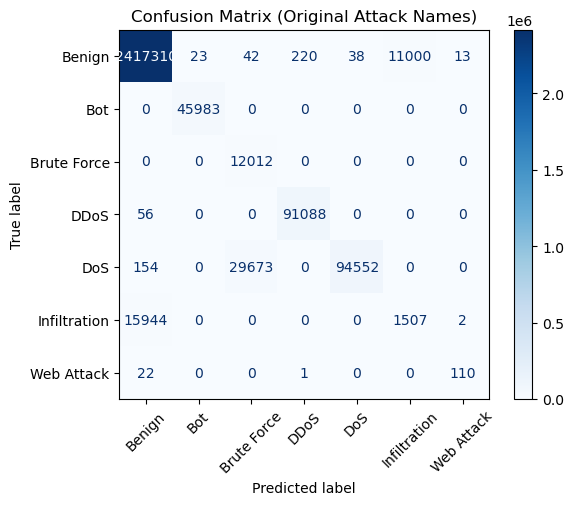

In [21]:
import joblib
import pandas as pd

# ===== Paths =====
model_path   = datapath+"xgb_SMOTE_Tomek_best_model2.pkl"

# ===== Load all objects =====
print("Loading model")

xgb_model = joblib.load(model_path)

# ===== Evaluate =====
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Test metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

# # ===== 8) Save artifacts =====
# joblib.dump(xgb_model, "D:/r6g/prog1/cicids2018/xgb_DS_best_model.pkl")

# print("Saved: xgb_model.pkl")

import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# ===== Load JSON mapping =====
with open(r"D:\fypadpm\proj1\mappings.json", "r") as f:
    mapping = json.load(f)

attack_type_mapping = mapping["attack_type_mapping"]   # dict: "0": "Benign", ...

# ===== Prepare label names (sorted by integer key) =====
unique_labels = sorted(list(set(y_test)))
attack_type_names = [attack_type_mapping[str(l)] for l in unique_labels]

# ===== Confusion Matrix =====
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

print("\nConfusion Matrix (Raw Values):")
print(cm)

# ===== Table Format =====
cm_df = pd.DataFrame(
    cm,
    index=[f"True {attack_type_mapping[str(l)]}" for l in unique_labels],
    columns=[f"Pred {attack_type_mapping[str(l)]}" for l in unique_labels]
)

print("\nConfusion Matrix (Table with Original Attack Names):")
display(cm_df)

# ===== Heatmap Plot =====
plt.figure(figsize=(12, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_type_names)
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix (Original Attack Names)")
plt.show()

## 1D-CNN Centralized T10

In [22]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import json
import joblib
import gc

# =====================================================
# 1️⃣ File paths
# =====================================================
paths = {
    "Train":      datapath+"Boruta_train_t10.csv",
    "Validation": datapath+"Boruta_validation_t10.csv",
    "Test":       datapath+"Boruta_test_t10.csv"
}

# =====================================================
# 2️⃣ Read CSV files
# =====================================================
df_train = pd.read_csv(paths["Train"])
df_test  = pd.read_csv(paths["Test"])
df_val   = pd.read_csv(paths["Validation"])

print("Loaded datasets:")
print("Train:", df_train.shape)
print("Test:", df_test.shape)
print("Validation:", df_val.shape)

# =====================================================
# 3️⃣ Split into X and y
# =====================================================
X_train = df_train.drop(columns=["Label","Attack_Type"]).values
y_train = df_train["Attack_Type"].values
X_val   = df_val.drop(columns=["Label","Attack_Type"]).values
y_val   = df_val["Attack_Type"].values
X_test  = df_test.drop(columns=["Label","Attack_Type"]).values
y_test  = df_test["Attack_Type"].values

del df_train, df_val, df_test
gc.collect()

NUM_FEATURES = X_train.shape[1]
NUM_CLASSES  = len(np.unique(y_train))

# =====================================================
# 4️⃣ Reshape for 1D-CNN
# =====================================================
X_train_cnn = X_train.reshape(-1, NUM_FEATURES, 1)
X_val_cnn   = X_val.reshape(-1, NUM_FEATURES, 1)
X_test_cnn  = X_test.reshape(-1, NUM_FEATURES, 1)

print("\nFinal shapes:")
print("X_train:", X_train_cnn.shape, " | y_train:", y_train.shape)
print("X_val:",   X_val_cnn.shape,   " | y_val:",   y_val.shape)
print("X_test:",  X_test_cnn.shape,  " | y_test:",  y_test.shape)
print(f"Features: {NUM_FEATURES}, Classes: {NUM_CLASSES}")

Loaded datasets:
Train: (10415163, 12)
Test: (2719750, 12)
Validation: (2603791, 12)

Final shapes:
X_train: (10415163, 10, 1)  | y_train: (10415163,)
X_val: (2603791, 10, 1)  | y_val: (2603791,)
X_test: (2719750, 10, 1)  | y_test: (2719750,)
Features: 10, Classes: 7


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,335 (263.03 KB)

 Trainable params: 66,951 (261.53 KB)

 Non-trainable params: 384 (1.50 KB)


🚀 Starting 1D-CNN Centralized Training...
Epoch 1/50
40685/40685 ━━━━━━━━━━━━━━━━━━━━ 338s 8ms/step - accuracy: 0.9839 - loss: 0.0699 - val_accuracy: 0.9858 - val_loss: 0.0682
Epoch 2/50
40685/40685 ━━━━━━━━━━━━━━━━━━━━ 317s 8ms/step - accuracy: 0.9870 - loss: 0.0570 - val_accuracy: 0.9792 - val_loss: 0.0873
Epoch 3/50
40685/40685 ━━━━━━━━━━━━━━━━━━━━ 328s 8ms/step - accuracy: 0.9877 - loss: 0.0548 - val_accuracy: 0.9852 - val_loss: 0.0623
Epoch 4/50
40685/40685 ━━━━━━━━━━━━━━━━━━━━ 324s 8ms/step - accuracy: 0.9880 - loss: 0.0538 - val_accuracy: 0.9296 - val_loss: 0.2678
Epoch 5/50
40685/40685 ━━━━━━━━━━━━━━━━━━━━ 313s 8ms/step - accuracy: 0.9880 - loss: 0.0533 - val_accuracy: 0.9545 - val_loss: 0.3524
Epoch 6/50
40685/40685 ━━━━━━━━━━━━━━━━━━━━ 342s 8ms/step - accuracy: 0.9881 - loss: 0.0530 - val_accuracy: 0.9883 - val_loss: 0.0527
Epoch 7/50
40685/40685 ━━━━━━━━━━━━━━━━━━━━ 337s 8ms/step - accuracy: 0.9881 - loss: 0.0529 - val_accuracy: 0.9595 - val_loss: 0.3023
Epoch 8/50
40685/40

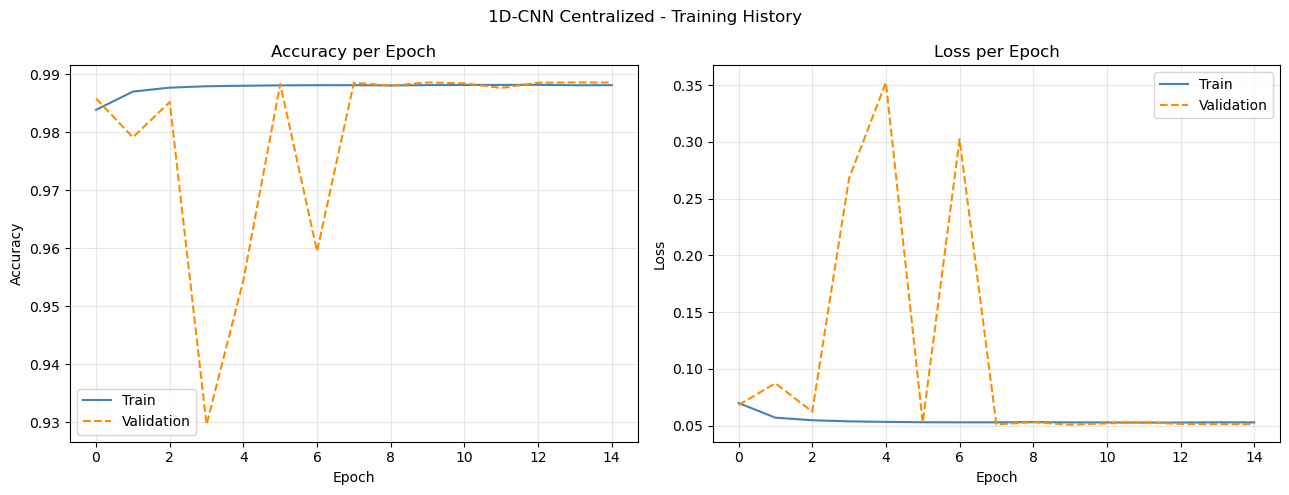

In [23]:
# =====================================================
# 1️⃣ Build model
# =====================================================
def build_1dcnn(num_features, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(num_features, 1)),
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_1dcnn(NUM_FEATURES, NUM_CLASSES)
model.summary()

# =====================================================
# 2️⃣ Train
# =====================================================
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("\n🚀 Starting 1D-CNN Centralized Training...")

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# =====================================================
# 3️⃣ Save model
# =====================================================
model.save(datapath+"1dcnn_centralized.keras")
print(f"\n✅ Model saved → {datapath}1dcnn_centralized.keras")

# =====================================================
# 4️⃣ Training curves
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(history.history['accuracy'], label='Train', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Validation', color='darkorange', linestyle='--')
ax1.set_title('Accuracy per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Train', color='steelblue')
ax2.plot(history.history['val_loss'], label='Validation', color='darkorange', linestyle='--')
ax2.set_title('Loss per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('1D-CNN Centralized - Training History')
plt.tight_layout()
plt.savefig(datapath+"1dcnn_training_curve.png", dpi=150)
plt.show()

Loading model
84993/84993 ━━━━━━━━━━━━━━━━━━━━ 136s 2ms/step
Test metrics:
  Accuracy : 0.9824
  Precision: 0.9854
  Recall   : 0.9824
  F1-Score : 0.9815

Confusion Matrix (Raw Values):
[[2428171     293      33      47      54      42       6]
 [      0   45983       0       0       0       0       0]
 [      0       0   12012       0       0       0       0]
 [     16       0       0   91128       0       0       0]
 [    105       0   29673       0   94601       0       0]
 [  17436       2       0       2       0      13       0]
 [     54       0       0       2       0       0      77]]

Confusion Matrix (Table with Original Attack Names):


,Pred Benign,Pred Bot,Pred Brute Force,Pred DDoS,Pred DoS,Pred Infiltration,Pred Web Attack
True Benign,2428171,293,33,47,54,42,6
True Bot,0,45983,0,0,0,0,0
True Brute Force,0,0,12012,0,0,0,0
True DDoS,16,0,0,91128,0,0,0
True DoS,105,0,29673,0,94601,0,0
True Infiltration,17436,2,0,2,0,13,0
True Web Attack,54,0,0,2,0,0,77


<Figure size 1200x800 with 0 Axes>

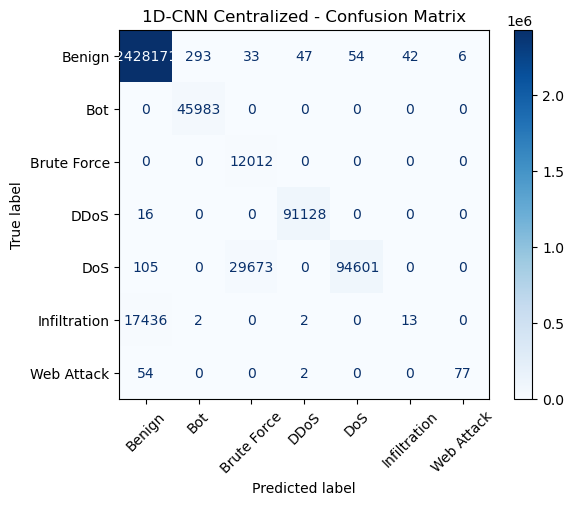

In [24]:
# =====================================================
# 1️⃣ Load model and evaluate
# =====================================================
print("Loading model")
cnn_model = keras.models.load_model(datapath+"1dcnn_centralized.keras")

y_pred_prob = cnn_model.predict(X_test_cnn)
y_pred      = np.argmax(y_pred_prob, axis=1)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Test metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

# =====================================================
# 2️⃣ Confusion Matrix
# =====================================================
with open(r"D:\fypadpm\proj1\mappings.json", "r") as f:
    mapping = json.load(f)
attack_type_mapping = mapping["attack_type_mapping"]

unique_labels     = sorted(list(set(y_test)))
attack_type_names = [attack_type_mapping[str(l)] for l in unique_labels]

cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

print("\nConfusion Matrix (Raw Values):")
print(cm)

cm_df = pd.DataFrame(
    cm,
    index=[f"True {attack_type_mapping[str(l)]}" for l in unique_labels],
    columns=[f"Pred {attack_type_mapping[str(l)]}" for l in unique_labels]
)
print("\nConfusion Matrix (Table with Original Attack Names):")
display(cm_df)

plt.figure(figsize=(12, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_type_names)
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("1D-CNN Centralized - Confusion Matrix")
plt.show()